# Data visualization tools for ML

Note: big portions of the code are AI generated for convenience (through Codex). While it is possible to generate good plots with AI, the insight from these plots remains important and required for manual decision making for machine learning. Preprocessing is often informed by what you see when you perform data visualization.

In [ ]:
# %pip install matplotlib pandas seaborn scikit-learn pathlib

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Find the folder where this Python file lives.
ROOT = Path.cwd()

# Read the summary file created by the full NASA battery script.
SUMMARY_CSV_PATH = "all_cycle_summary.csv"

# Save new plots in a separate folder so we do not overwrite the full lesson.
OUTPUT_DIR = ROOT / "OUTPUTS"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# NASA states that end of life occurs at 30% capacity fade from 2.0 Ah to 1.4 Ah.
RATED_CAPACITY_AH = 2.0
END_OF_LIFE_CAPACITY_AH = 1.4

In [ ]:
# This CSV is already flat, so students can start directly with pandas.
cycles_df = pd.read_csv(SUMMARY_CSV_PATH)

# Convert the saved text timestamps back into datetime values.
cycles_df["start_time"] = pd.to_datetime(cycles_df["start_time"])

print("\nCycle summary shape:")
print(cycles_df.shape)

print("\nFirst five rows:")
print(cycles_df.head())

print("\nOperation counts:")
print(cycles_df["operation_type"].value_counts())


Cycle summary shape:
(2167, 20)

First five rows:
  battery_id  cycle_index operation_type  ambient_temperature_C  \
0      B0005            0         charge                   24.0   
1      B0005            1      discharge                   24.0   
2      B0005            2         charge                   24.0   
3      B0005            3      discharge                   24.0   
4      B0005            4         charge                   24.0   

           start_time  charge_cycle  duration_s  mean_voltage_V  \
0 2008-04-02 13:08:17           1.0    7597.875        4.187420   
1 2008-04-02 15:25:41           NaN    3690.234        3.529829   
2 2008-04-02 16:37:51           2.0   10516.000        4.058826   
3 2008-04-02 19:43:48           NaN    3672.344        3.537320   
4 2008-04-02 20:55:40           3.0   10484.547        4.058139   

   max_voltage_V  mean_current_A  mean_charger_current_A  \
0       4.209949        0.643455                0.638452   
1            NaN       

In [ ]:
# Each operation state has different physical meaning and different useful columns. We will split the dataframe into seperate dataframes for each operation type. This will make it easier to plot and analyze the data.
charge_df = cycles_df[cycles_df["operation_type"] == "charge"].copy()
discharge_df = cycles_df[cycles_df["operation_type"] == "discharge"].copy()
impedance_df = cycles_df[cycles_df["operation_type"] == "impedance"].copy()

# Sort each state table by battery and cycle number before plotting.
charge_df = charge_df.sort_values(["battery_id", "charge_cycle"])
discharge_df = discharge_df.sort_values(["battery_id", "discharge_cycle"])
impedance_df = impedance_df.sort_values(["battery_id", "cycle_index"])

# Add health labels to the discharge table because capacity is measured during discharge.
discharge_df["max_discharge_cycle"] = discharge_df.groupby("battery_id")["discharge_cycle"].transform("max")
discharge_df["remaining_cycles"] = discharge_df["max_discharge_cycle"] - discharge_df["discharge_cycle"]
discharge_df["below_EOL_threshold"] = discharge_df["capacity_Ah"] <= END_OF_LIFE_CAPACITY_AH
discharge_df["capacity_loss_percent"] = 100 * (RATED_CAPACITY_AH - discharge_df["capacity_Ah"]) / RATED_CAPACITY_AH


Operation counts:    battery_id operation_type  count
0       B0005         charge    170
1       B0005      discharge    168
2       B0005      impedance    278
3       B0006         charge    170
4       B0006      discharge    168
5       B0006      impedance    278
6       B0007         charge    170
7       B0007      discharge    168
8       B0007      impedance    278
9       B0018         charge    134
10      B0018      discharge    132
11      B0018      impedance     53


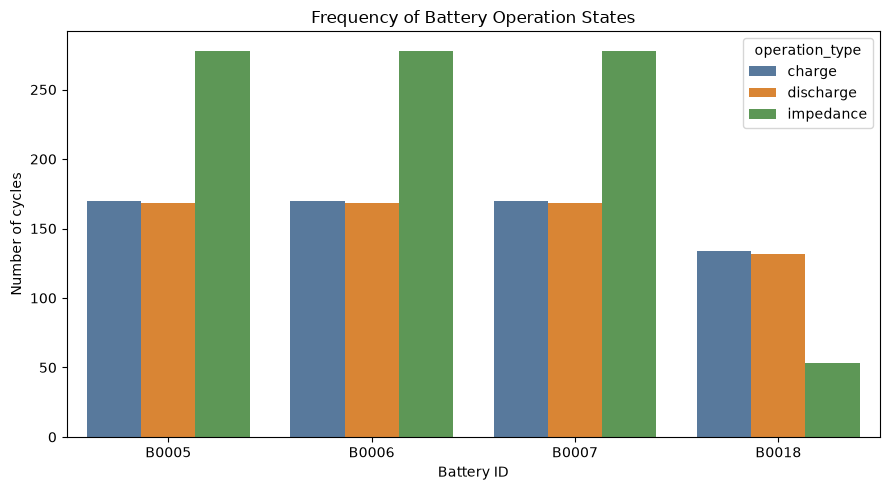

In [ ]:
# Count how many charge, discharge, and impedance cycles each battery has. This is important to see how much data is avaialable for training the machine learning models. Generally, more powerful machine learning models require more training data.

operation_counts = (
    cycles_df.groupby(["battery_id", "operation_type"])
    .size()
    .rename("count")
    .reset_index()
)

print("\nOperation counts:", operation_counts)
operation_counts.to_csv(OUTPUT_DIR / "operation_state_counts.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=operation_counts,
    x="battery_id",
    y="count",
    hue="operation_type",
    palette=["#4C78A8", "#F58518", "#54A24B"],
)
plt.title("Frequency of Battery Operation States")
plt.xlabel("Battery ID")
plt.ylabel("Number of cycles")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_operation_state_frequency.png", dpi=180)


Missing-data summary:
                        missing_count  missing_percent
min_voltage_V                    1531        70.650669
state_of_health                  1531        70.650669
capacity_Ah                      1531        70.650669
discharge_cycle                  1531        70.650669
max_voltage_V                    1524        70.327642
mean_charger_current_A           1523        70.281495
mean_charger_voltage_V           1523        70.281495
charge_cycle                     1523        70.281495
Re_ohm                           1280        59.067836
Rct_ohm                          1280        59.067836
mean_current_A                    888        40.978311
mean_temperature_C                888        40.978311
max_temperature_C                 888        40.978311
mean_voltage_V                    888        40.978311
duration_s                        887        40.932164
cycle_index                         0         0.000000
start_time                          0     

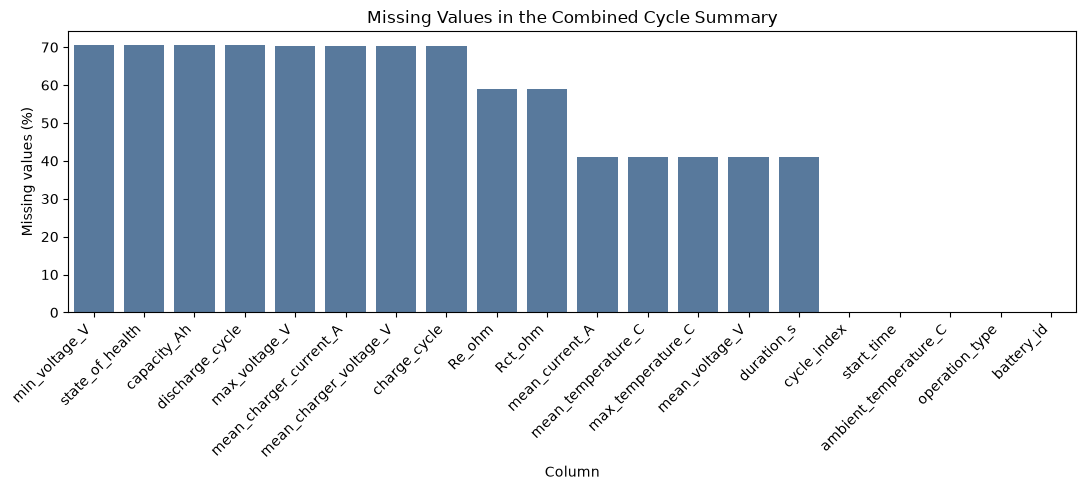

In [ ]:
# In the combined summary table, many blank cells are expected.
# Example: capacity exists for discharge, but not for charge or impedance.
missing_summary = pd.DataFrame(
    {
        "missing_count": cycles_df.isna().sum(),
        "missing_percent": 100 * cycles_df.isna().sum() / len(cycles_df),
    }
).sort_values("missing_percent", ascending=False)

missing_summary.to_csv(OUTPUT_DIR / "missing_data_summary.csv")

print("\nMissing-data summary:")
print(missing_summary)

plt.figure(figsize=(11, 5))

#Notice that the x-axis is the column name, which is why we reset the index to make it a column.

sns.barplot(
    data=missing_summary.reset_index(),
    x="index",
    y="missing_percent",
    color="#4C78A8",
)
plt.title("Missing Values in the Combined Cycle Summary")
plt.xlabel("Column")
plt.ylabel("Missing values (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_missing_values_bar_chart.png", dpi=180)

## Discharge Operation Plots

Overall insights:
Capcity and State of Health appear to have a direct inverse relationship with the Discharge Cycle.

Battery Capacity and Discharge time seem to be positively related across different batteries (generally linear with some tapering towards the end)

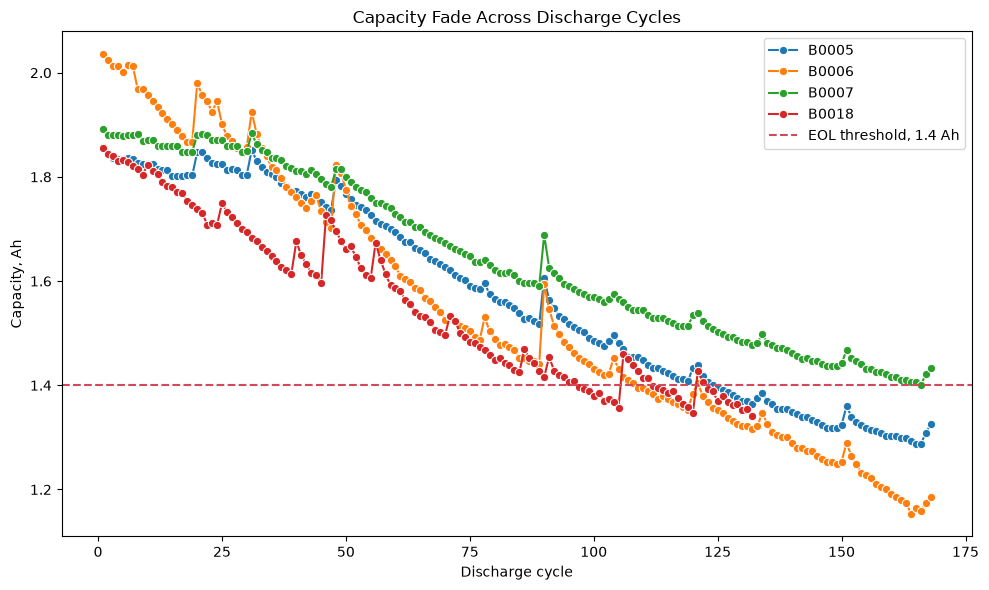

In [ ]:

# Capacity fade is the main degradation target in this dataset.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=discharge_df,
    x="discharge_cycle",
    y="capacity_Ah",
    hue="battery_id",
    marker="o",
    linewidth=1.5,
)
plt.axhline(END_OF_LIFE_CAPACITY_AH, color="#D1495B", linestyle="--", label="EOL threshold, 1.4 Ah")
plt.title("Capacity Fade Across Discharge Cycles")
plt.xlabel("Discharge cycle")
plt.ylabel("Capacity, Ah")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_capacity_fade.png", dpi=180)


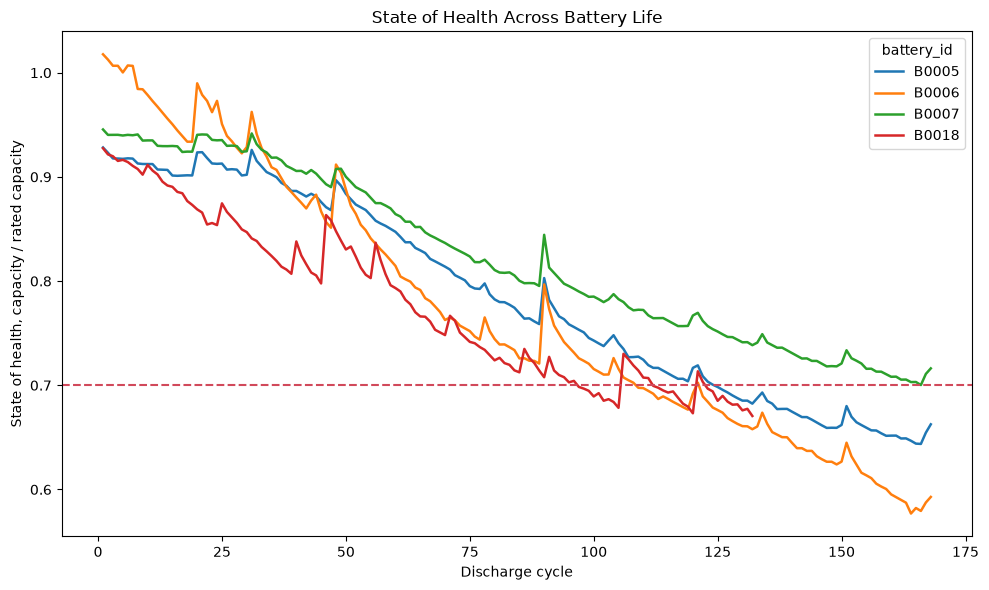

In [7]:
# State of health normalizes capacity by the rated capacity.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=discharge_df,
    x="discharge_cycle",
    y="state_of_health",
    hue="battery_id",
    linewidth=1.8,
)
plt.axhline(END_OF_LIFE_CAPACITY_AH / RATED_CAPACITY_AH, color="#D1495B", linestyle="--")
plt.title("State of Health Across Battery Life")
plt.xlabel("Discharge cycle")
plt.ylabel("State of health, capacity / rated capacity")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_state_of_health.png", dpi=180)

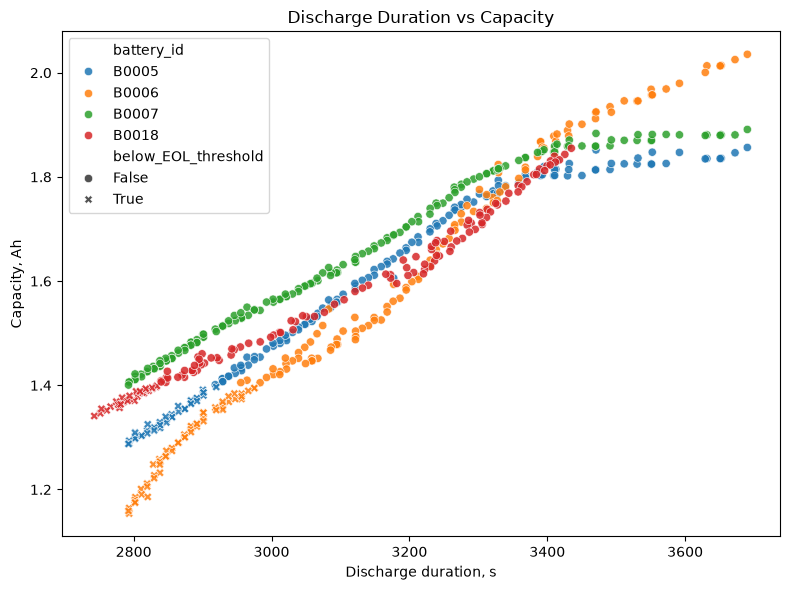

In [8]:
# Discharge duration is a strong engineered feature for battery capacity.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=discharge_df,
    x="duration_s",
    y="capacity_Ah",
    hue="battery_id",
    style="below_EOL_threshold",
    alpha=0.85,
)
plt.title("Discharge Duration vs Capacity")
plt.xlabel("Discharge duration, s")
plt.ylabel("Capacity, Ah")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_discharge_duration_vs_capacity.png", dpi=180)

## Charge Operation Plots

Important insights:

Its appears that there are some outlyers that exist in the charging data. The charge duration appears constant over different charging cycles with only a few points being off. These points might be related to experimental conditions that are unreported. Generally, its ok to eliminate outlyers if they are: (1) uncommon, (2) significantly away from the rest of the data. You will see below that I will drop the rows that include these spikes. When doing so, it turns out that batteries B0005 and B0006 have very similar spikes to B0007 while being obscured behind it. The spikes are removed for these batteries as well.

Overall, other parameters seem consistent. The charge current and voltage appear to cluster together across the dataset.

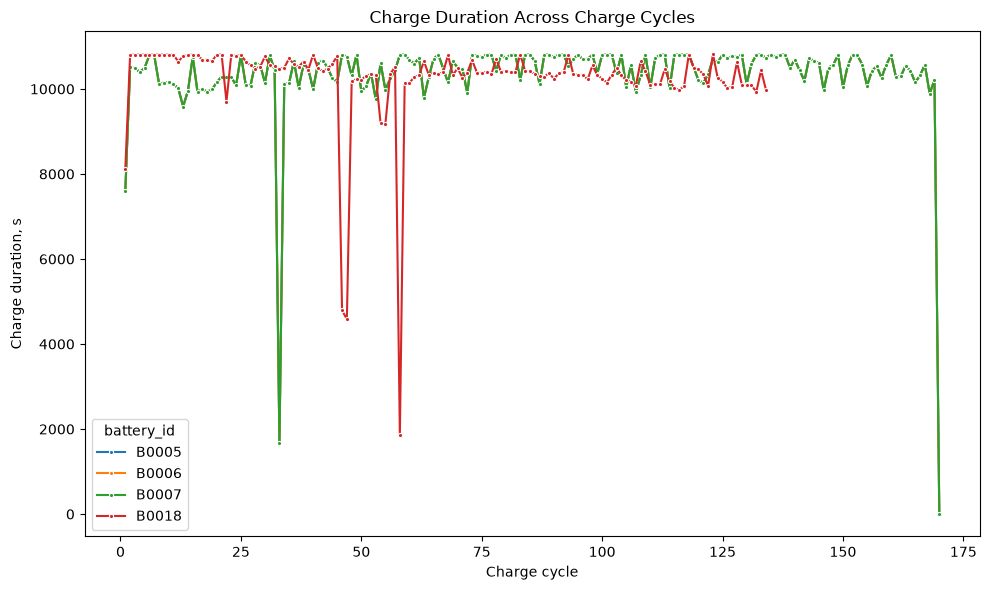

In [ ]:
# Charge duration can change across cycling and is a state-specific signal.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=charge_df,
    x="charge_cycle",
    y="duration_s",
    hue="battery_id",
    marker="o",
    linewidth=1.5,
    markersize=3,
)
plt.title("Charge Duration Across Charge Cycles")
plt.xlabel("Charge cycle")
plt.ylabel("Charge duration, s")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_charge_duration.png", dpi=180)

Below, I will be removing the spikes for convenience to get a better view of my data without outlyers. Note: the figure scale is different than the previous figure

/var/folders/7m/v1zp3mf57nxbckxdpbwx_8dw0000gp/T/ipykernel_76585/4023159599.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  LowIndices1 = charge_df[charge_df["duration_s"] <= 8200][charge_df["battery_id"] == "B0018"].index
/var/folders/7m/v1zp3mf57nxbckxdpbwx_8dw0000gp/T/ipykernel_76585/4023159599.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  LowIndices2 = charge_df[charge_df["duration_s"] <= 8000][charge_df["battery_id"] == "B0007"].index
/var/folders/7m/v1zp3mf57nxbckxdpbwx_8dw0000gp/T/ipykernel_76585/4023159599.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  LowIndices3 = charge_df[charge_df["duration_s"] <= 8000][charge_df["battery_id"] == "B0006"].index
/var/folders/7m/v1zp3mf57nxbckxdpbwx_8dw0000gp/T/ipykernel_76585/4023159599.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  LowIndices4 = charge_df[charge_df["duration_s"] <= 8000][charge

(631, 20)


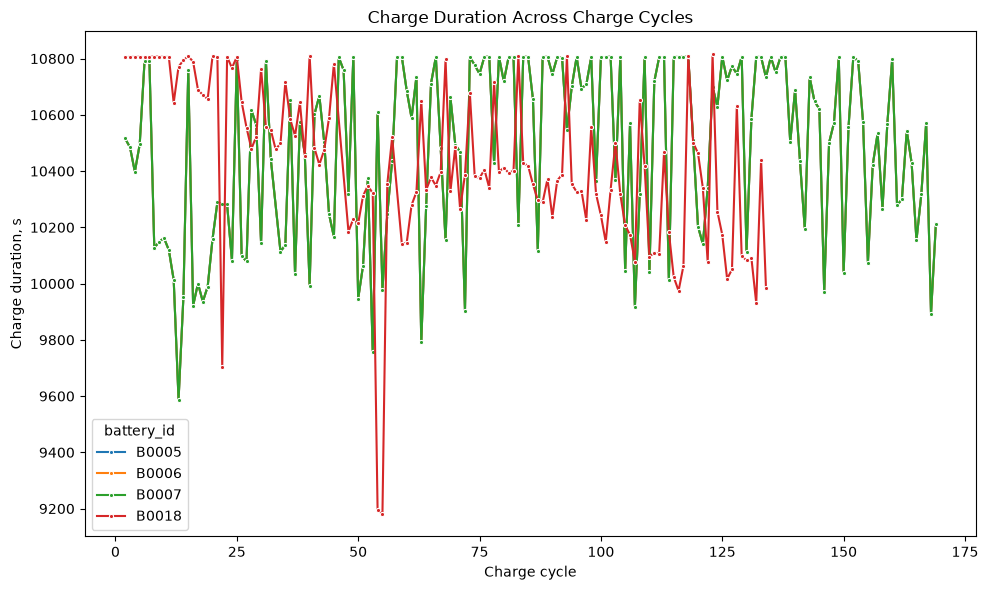

In [53]:
#Find the indices of the spikes characterized by a lower charge time (depending on the battery).

LowIndices1 = charge_df[charge_df["duration_s"] <= 8200][charge_df["battery_id"] == "B0018"].index
LowIndices2 = charge_df[charge_df["duration_s"] <= 8000][charge_df["battery_id"] == "B0007"].index
LowIndices3 = charge_df[charge_df["duration_s"] <= 8000][charge_df["battery_id"] == "B0006"].index
LowIndices4 = charge_df[charge_df["duration_s"] <= 8000][charge_df["battery_id"] == "B0005"].index
#Some indicies are repeated in the list, so we will combine them into one list and drop them from the dataframe.
LowIndices = list(LowIndices1) + list(LowIndices2) + list(LowIndices3) + list(LowIndices4)
#The new dataframe excludes the low duration spikes, which are likely due to measurement errors or anomalies in the charging process.
charge_df_with_drop = charge_df.drop(LowIndices)
print(charge_df_with_drop.shape)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=charge_df_with_drop,
    x="charge_cycle",
    y="duration_s",
    hue="battery_id",
    marker="o",
    linewidth=1.5,
    markersize=3,
)
plt.title("Charge Duration Across Charge Cycles")
plt.xlabel("Charge cycle")
plt.ylabel("Charge duration, s")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_charge_duration.png", dpi=180)

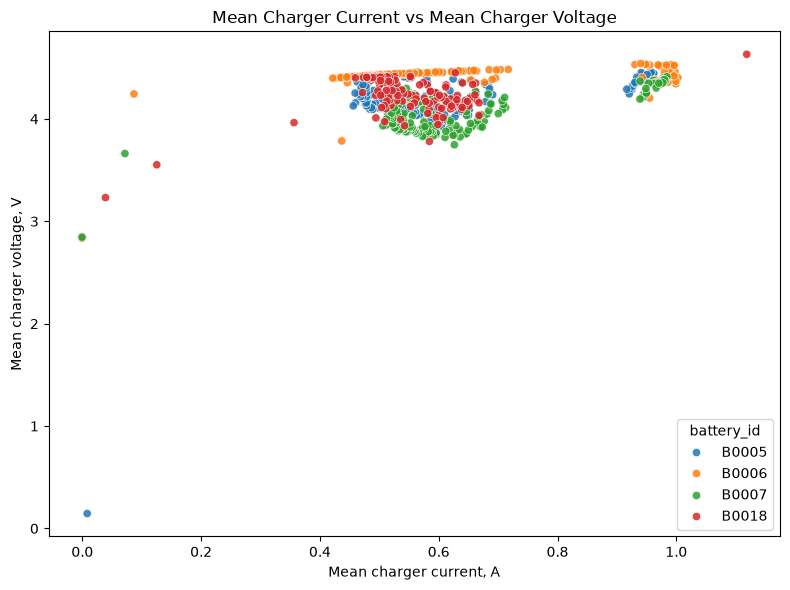

In [10]:
# Mean charger current and voltage summarize the charging state.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_df,
    x="mean_charger_current_A",
    y="mean_charger_voltage_V",
    hue="battery_id",
    alpha=0.85,
)
plt.title("Mean Charger Current vs Mean Charger Voltage")
plt.xlabel("Mean charger current, A")
plt.ylabel("Mean charger voltage, V")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_charger_current_vs_voltage.png", dpi=180)

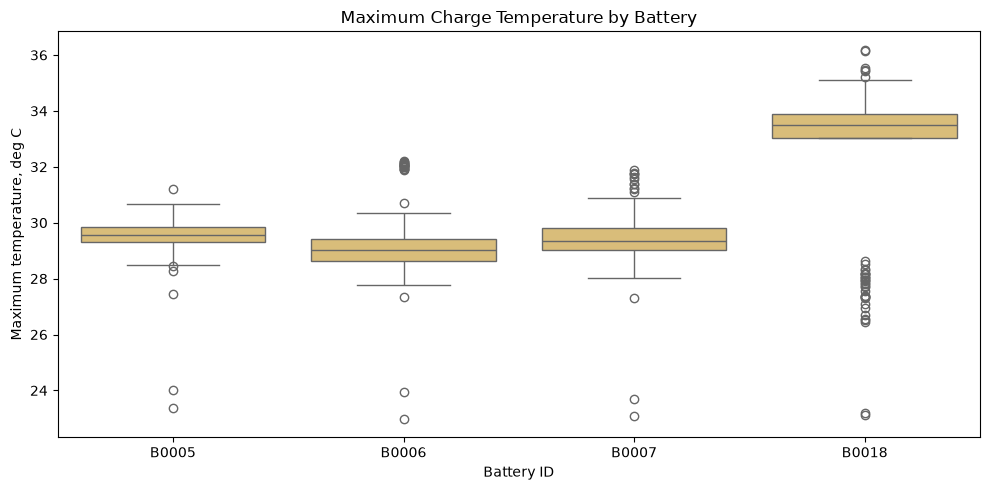

In [ ]:
# Compare thermal behavior during charging across batteries.
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=charge_df,
    x="battery_id",
    y="max_temperature_C",
    color="#E9C46A",
)
plt.title("Maximum Charge Temperature by Battery")
plt.xlabel("Battery ID")
plt.ylabel("Maximum temperature, deg C")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_charge_temperature_boxplot.png", dpi=180)

## Impedance Operation Plots

The resistance of a battery is known to change as its charge carrying capacity deteriorates. Here, we see that through the Re_ohm and Rct_ohm terms.

The plots show relatively consistent increase in both over cycles of impedance testing. The two values are also nearly linearly related to one another.

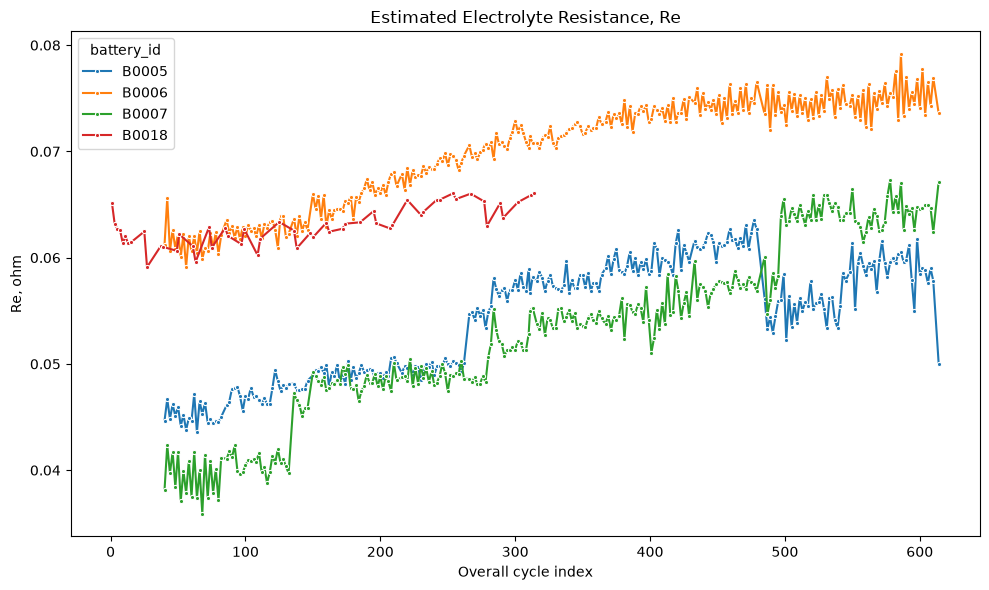

In [ ]:
# Internal resistance estimates usually increase or shift as cells age.
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=impedance_df,
    x="cycle_index",
    y="Re_ohm",
    hue="battery_id",
    marker="o",
    linewidth=1.5,
    markersize=3,
)
plt.title("Estimated Electrolyte Resistance, Re")
plt.xlabel("Overall cycle index")
plt.ylabel("Re, ohm")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_electrolyte_resistance.png", dpi=180)

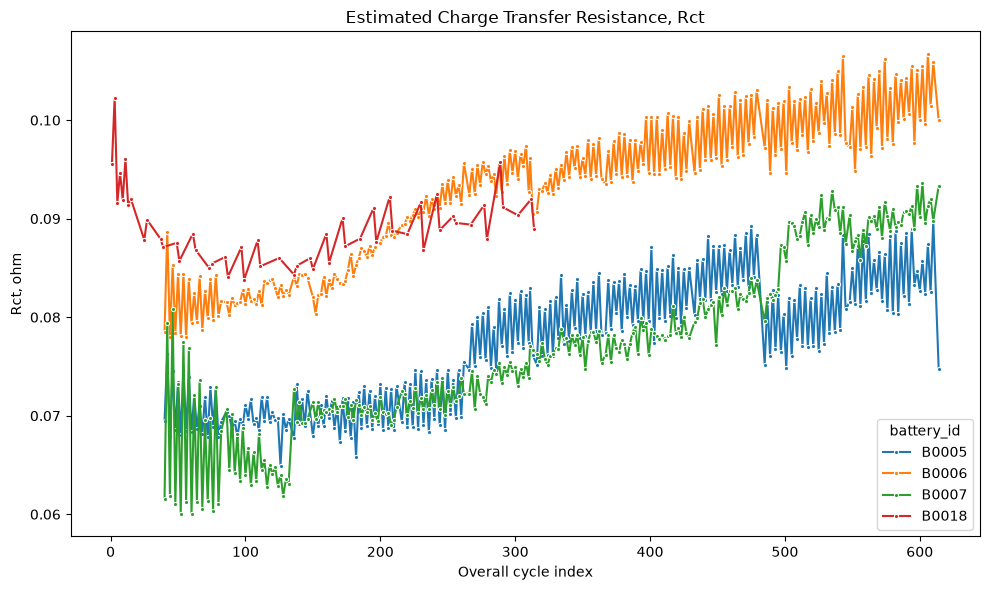

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=impedance_df,
    x="cycle_index",
    y="Rct_ohm",
    hue="battery_id",
    marker="o",
    linewidth=1.5,
    markersize=3,
)
plt.title("Estimated Charge Transfer Resistance, Rct")
plt.xlabel("Overall cycle index")
plt.ylabel("Rct, ohm")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_charge_transfer_resistance.png", dpi=180)

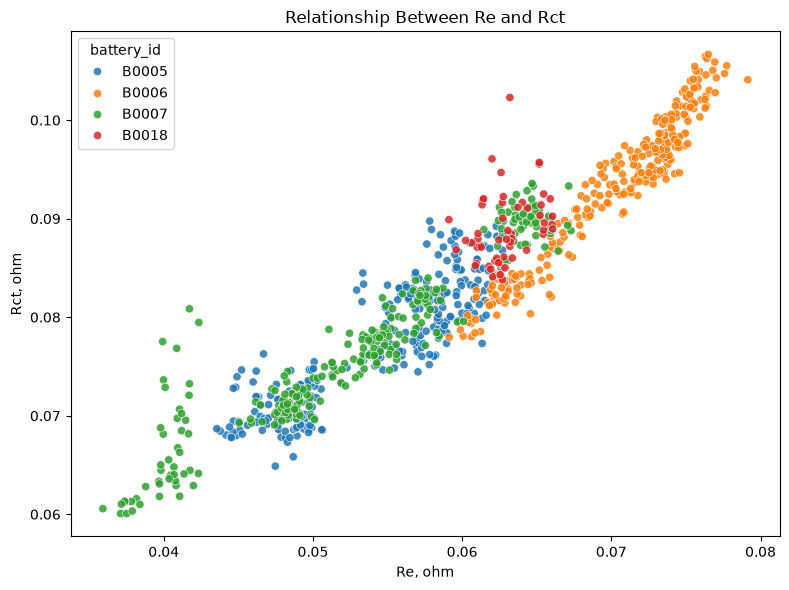

In [14]:

# A scatter plot shows how the two impedance estimates move together.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=impedance_df,
    x="Re_ohm",
    y="Rct_ohm",
    hue="battery_id",
    alpha=0.85,
)
plt.title("Relationship Between Re and Rct")
plt.xlabel("Re, ohm")
plt.ylabel("Rct, ohm")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_impedance_relationship.png", dpi=180)

# Comparison Across Operations

Lastly, we can look into summaries of some states that are common across all operations (ex: Duration and Mean Temperature). There is a lot going on in these plots, so its often a good idea to use a plotting scheme that is heavily descriptive like box plots. In these plots, you will see:
- A box (of different colors) representing the upper and lower 25% quartile
- A line within the box representing the median. 50% of the data is above/below it
- Whiskers showing maximum values within the data
- Floating outliers that are $\pm$ 50% of the maximum/minumum

Simply looking at a figure like this gives you a quick glance at a decent summary of large data, which is why box plots are fairly popular in machine learning and data science.

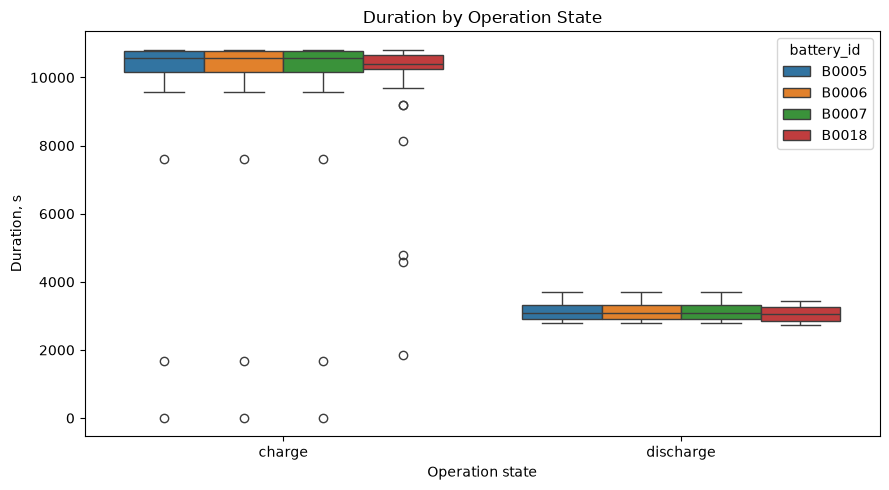

In [ ]:
# Duration is available for charge and discharge, so it can compare those states.
charge_discharge_df = cycles_df[cycles_df["operation_type"].isin(["charge", "discharge"])].copy()

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=charge_discharge_df,
    x="operation_type",
    y="duration_s",
    hue="battery_id",
)
plt.title("Duration by Operation State")
plt.xlabel("Operation state")
plt.ylabel("Duration, s")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_charge_vs_discharge_duration.png", dpi=180)

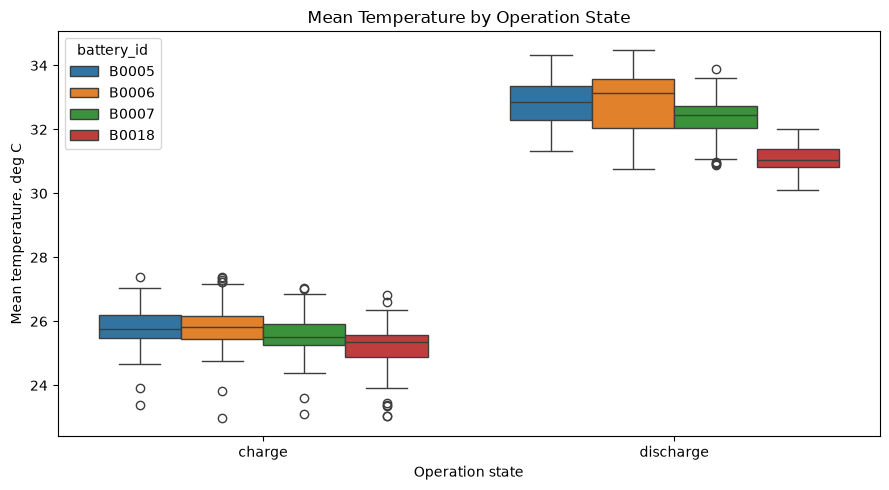

In [ ]:
# Mean temperature is available for charge and discharge summaries.
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=charge_discharge_df,
    x="operation_type",
    y="mean_temperature_C",
    hue="battery_id",
)
plt.title("Mean Temperature by Operation State")
plt.xlabel("Operation state")
plt.ylabel("Mean temperature, deg C")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_charge_vs_discharge_temperature.png", dpi=180)

# Correlation Plots

A Pandas dataframe has a method called "corr", which finds the linear correlation between its quantities. You can plot the correlation between the quantities using a headmap.

Ignore the diagonal of the heatmap, as it indicates a perfect linear correlation between a parameter and itself (duh!). One half of the heatmap is sufficient as the heatmap is symmetric.

+1: Indicates a perfect linear proportional relationship between terms
-1: Indicates a perfect linear inverse relationship between terms
0: Indicates no linear relationship between the terms

While the relationship between parameters may not be linear (and hence, a 0 may not necessarily mean no relationship at all), this may mean that some parameters may be disregarded when it comes to our machine learning model.

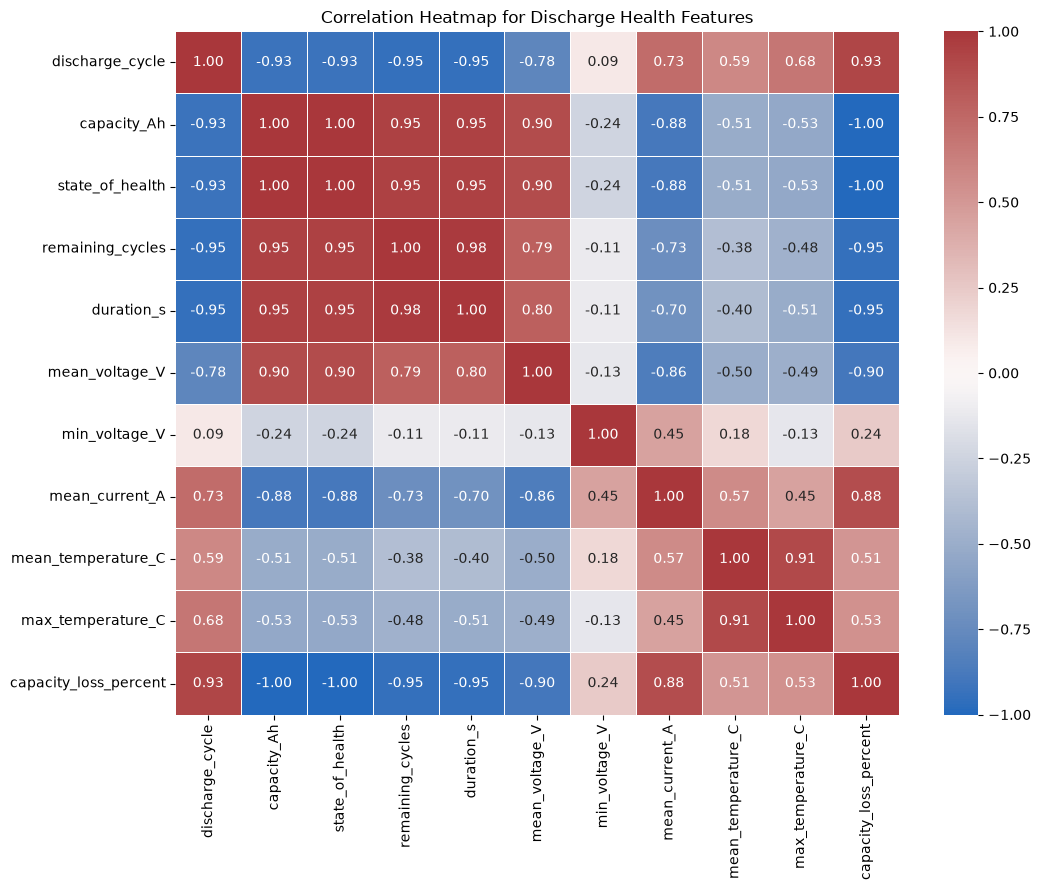

In [ ]:
# Correlation helps identify redundant features and possible target leakage.
correlation_columns = [
    "discharge_cycle",
    "capacity_Ah",
    "state_of_health",
    "remaining_cycles",
    "duration_s",
    "mean_voltage_V",
    "min_voltage_V",
    "mean_current_A",
    "mean_temperature_C",
    "max_temperature_C",
    "capacity_loss_percent",
]

correlation_matrix = discharge_df[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Heatmap for Discharge Health Features")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_discharge_correlation_heatmap.png", dpi=180)